# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore the cleaned dataset, identify patterns, understand customer characteristics, and discover relationships between customer attributes and churn. The insights gained will guide feature engineering and model development.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/processed/bank_customer_churn_clean.csv")

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 11)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
products_number,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
credit_card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
active_member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
estimated_salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
churn,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [5]:
df["churn"].value_counts()

0    7963
1    2037
Name: churn, dtype: int64

In [8]:
df["churn"].value_counts(normalize=True) * 100

0    79.63
1    20.37
Name: churn, dtype: float64

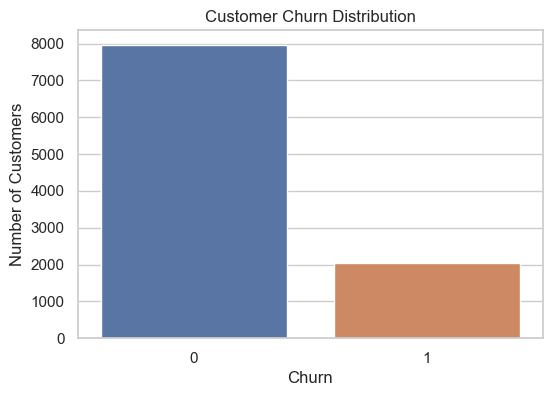

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.savefig("../images/churn_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: The target variable is moderately imbalanced, with roughly 80% of customers retained and 20% churned. This indicates that accuracy alone may not be an appropriate evaluation metric during model development. Metrics such as Precision, Recall, F1-score, and ROC-AUC should also be considered to better assess model performance.

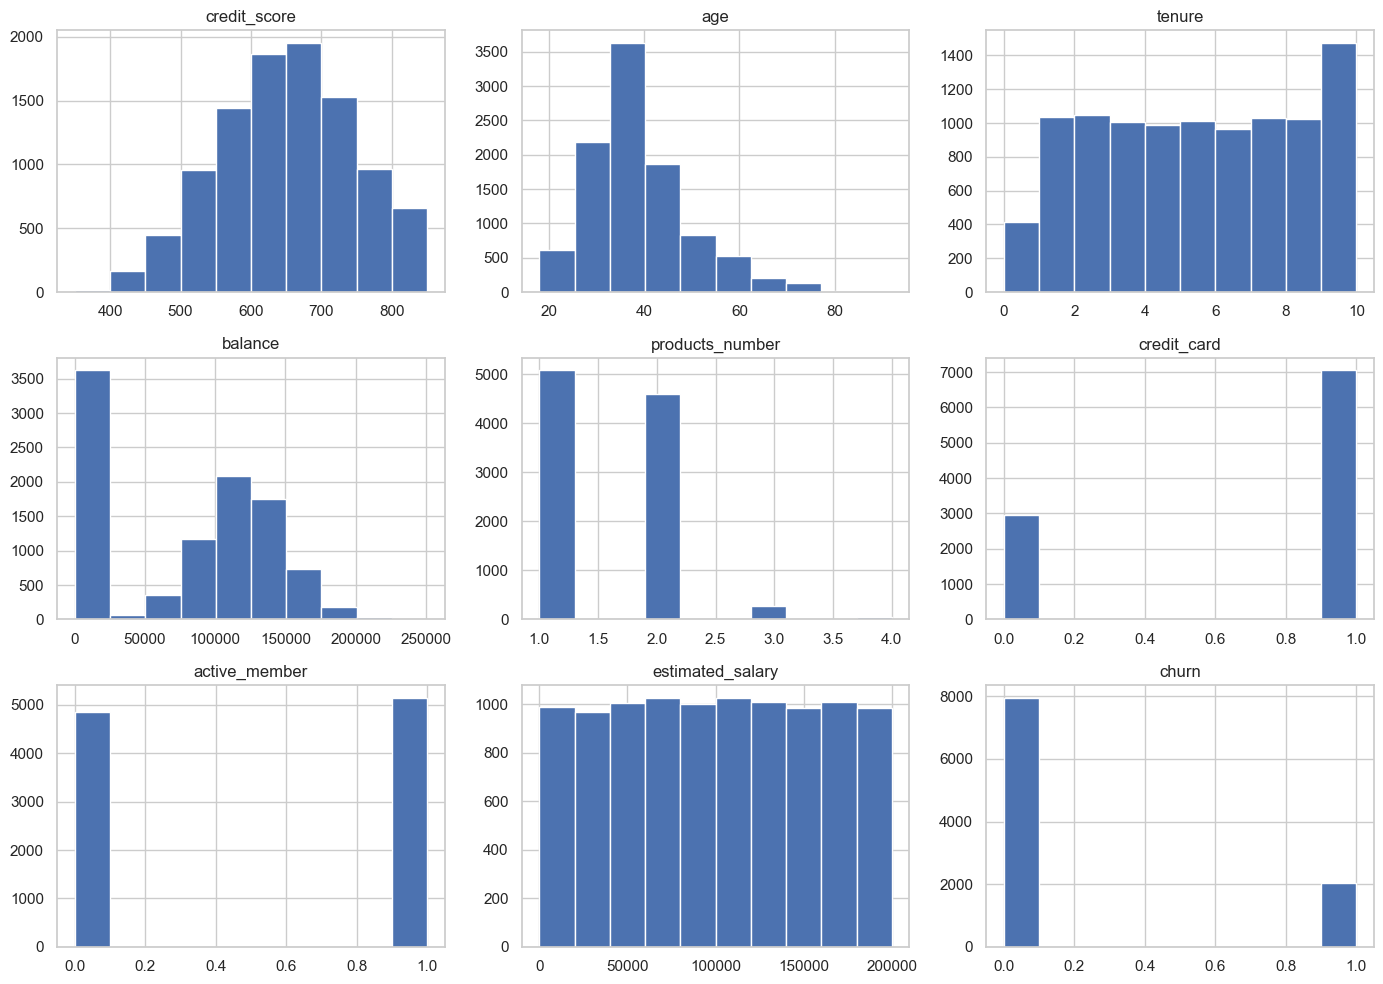

In [10]:
df.hist(figsize=(14,10))

plt.tight_layout()

plt.show()

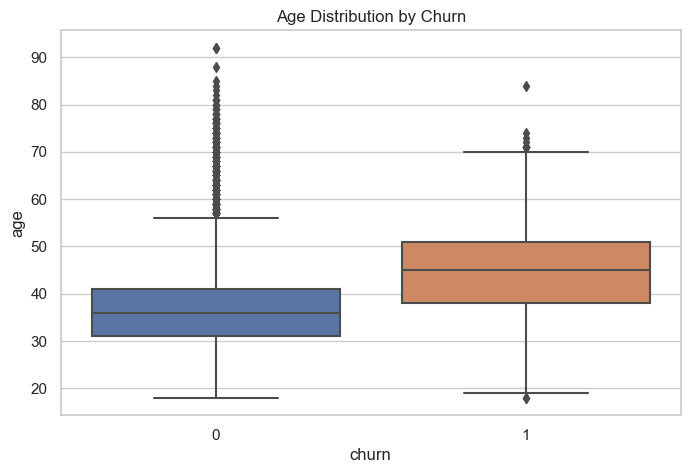

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="age"
)

plt.title("Age Distribution by Churn")

plt.savefig("../images/age_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Customers who churn tend to be older than customers who remain with the bank, as indicated by the higher median of around 45, compared to about 35 for retained customers, and upward-shifted age distribution. Although several statistical outliers are present, these represent plausible customer ages and are going to be retained because they are likely valid observations. The visualization suggests that age may be an important predictor of churn and should be retained for model development.

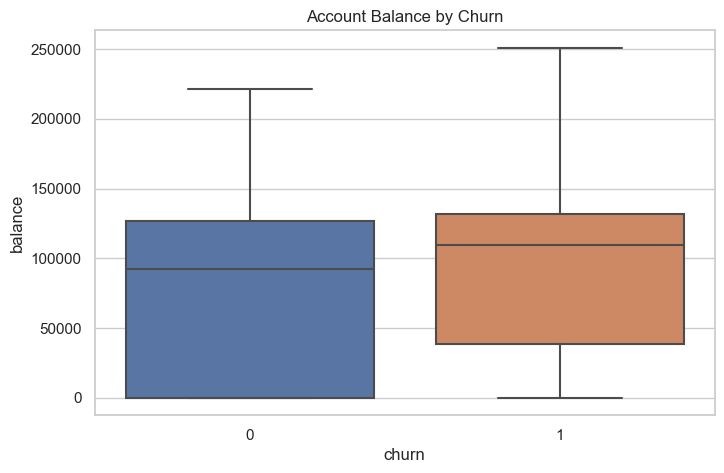

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="balance"
)

plt.title("Account Balance by Churn")

plt.savefig("../images/balance_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Customers who churn tend to have somewhat higher account balances than those who stay, the median balance for churned customers (~109k) is higher than for retained customers (~92k). Notably, a large share of retained customers have a balance of exactly zero, while churned customers are less likely to have a zero balance. Balance appears to be a potentially useful predictor, though the overlap between groups is considerable.

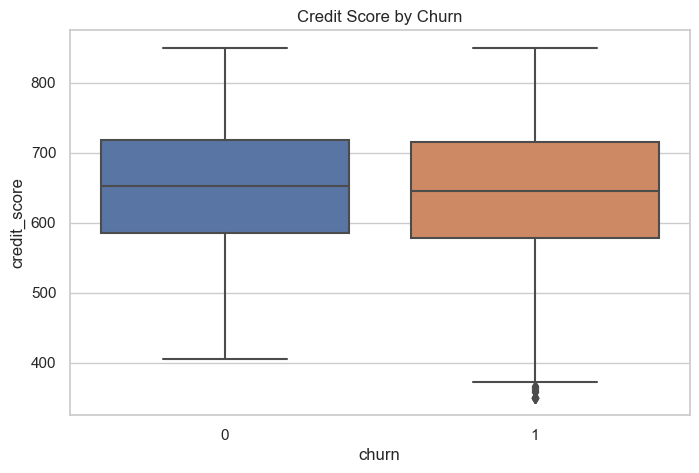

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="credit_score"
)

plt.title("Credit Score by Churn")

plt.savefig("../images/creditscore_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Credit score distributions between churned and retained customers are relatively similar, with only minor differences in their medians and spread. This suggests that credit score alone may have limited predictive power, although it could still contribute useful information when combined with other variables.

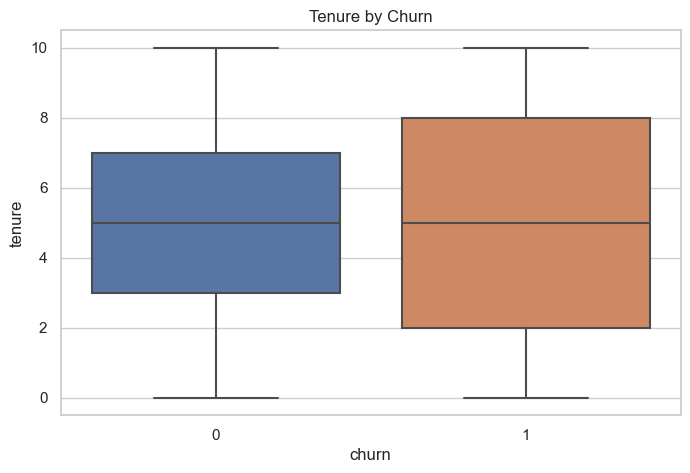

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="tenure"
)

plt.title("Tenure by Churn")

plt.savefig("../images/tenure_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Customer tenure shows considerable overlap between churned and retained customers, indicating that the length of the customer relationship alone is not a strong differentiator of churn behavior. Additional behavioral and financial variables will likely provide stronger predictive value.

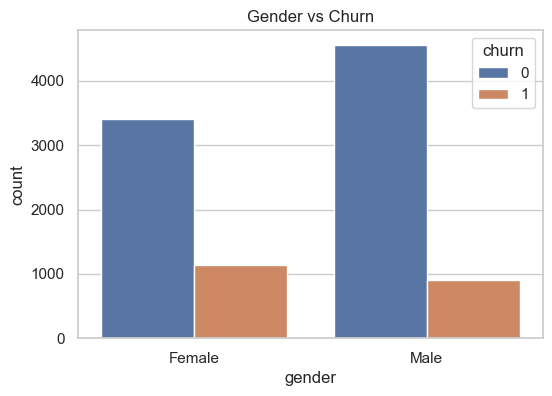

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="churn"
)

plt.title("Gender vs Churn")

plt.savefig("../images/gender_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observations: Churn appears notably higher among female customers than male customers visually, female customers show a higher proportion of churn relative to their group size than male customers do, even though male customers make up a larger share of the overall base. Gender appears to be a meaningful factor and should be retained as a candidate feature.

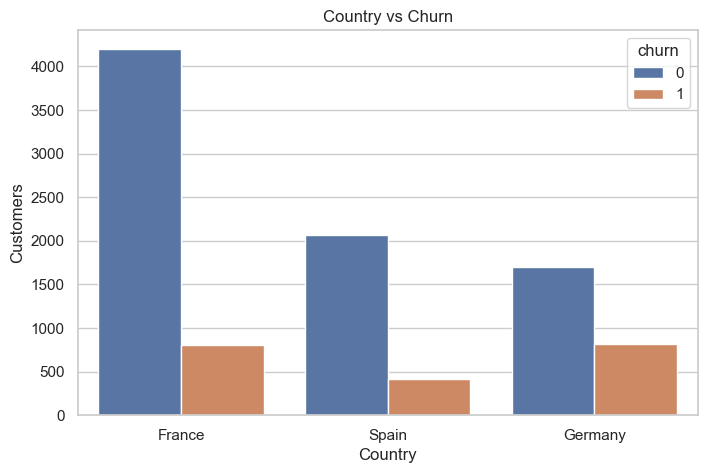

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="country",
    hue="churn"
)

plt.title("Country vs Churn")

plt.xlabel("Country")

plt.ylabel("Customers")

plt.savefig("../images/country_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observations: Churn rates vary across countries, indicating that geographic location may influence customer retention. France has the largest customer base but a relatively low churn share, Germany shows a much higher proportion of churned customers relative to its total, and Spain shows the lowest churn share.These differences may reflect variations in customer demographics, banking preferences, or regional market conditions. Country should therefore be retained as a categorical feature during model development.

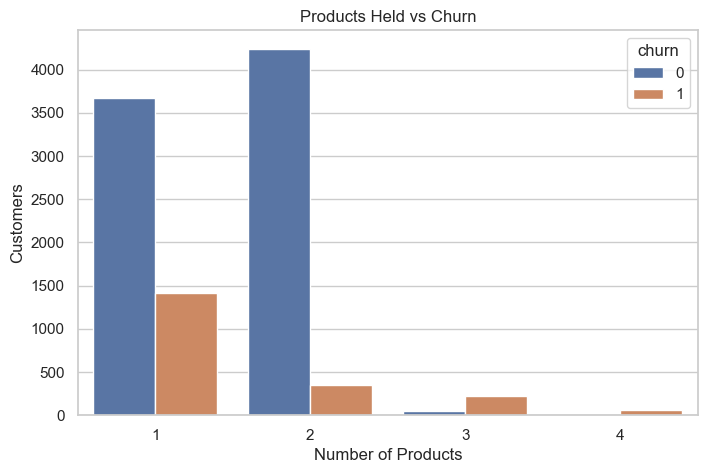

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="products_number",
    hue="churn"
)

plt.title("Products Held vs Churn")

plt.xlabel("Number of Products")

plt.ylabel("Customers")

plt.savefig("../images/products_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observations: The relationship between number of products and churn is not straightforward. Customers with 2 products show the strongest retention (very few churned relative to the group size), customers with 1 product show a higher proportion of churn, and customers with 3 or 4 products, while a much smaller group overall churn at a very high rate, in some cases with more churned than retained customers. This U-shaped pattern suggests number of products is an important feature but not one with a simple linear relationship to churn.

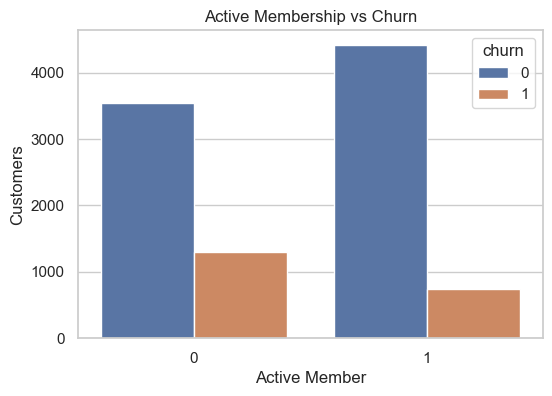

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="active_member",
    hue="churn"
)

plt.title("Active Membership vs Churn")

plt.xlabel("Active Member")

plt.ylabel("Customers")

plt.savefig("../images/active_member_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Active members show a noticeably lower proportion of churn than inactive members. This suggests customer engagement plays an important role in retention, and active membership is expected to be a strong predictor in the model.

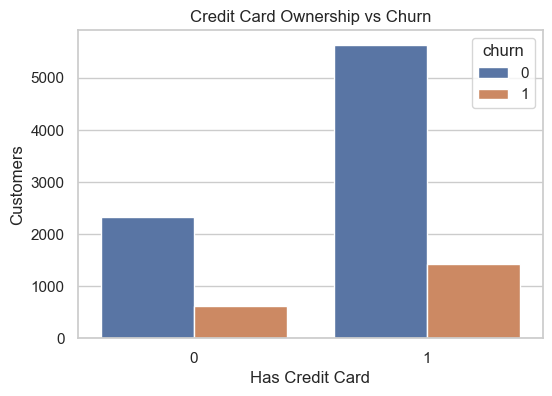

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="credit_card",
    hue="churn"
)

plt.title("Credit Card Ownership vs Churn")

plt.xlabel("Has Credit Card")

plt.ylabel("Customers")

plt.savefig("../images/creditcard_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observations: Customers with and without credit cards exhibit similar churn patterns. While credit card ownership may contribute modest predictive information, it does not appear to independently explain customer attrition.

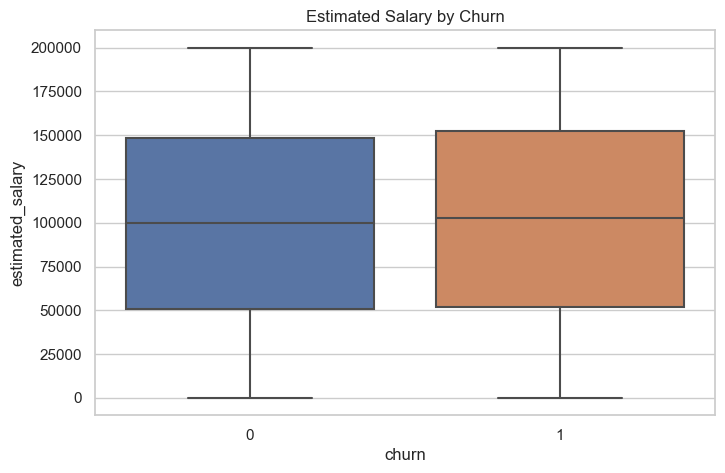

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn",
    y="estimated_salary"
)

plt.title("Estimated Salary by Churn")

plt.savefig("../images/salary_churn.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Estimated salary distributions are highly similar between churned and retained customers, indicating that salary alone does not strongly influence customer churn. While it may contribute to predictive performance when combined with other variables, it does not appear to be a dominant standalone predictor.

In [18]:
numeric_df = df.select_dtypes(include=np.number)

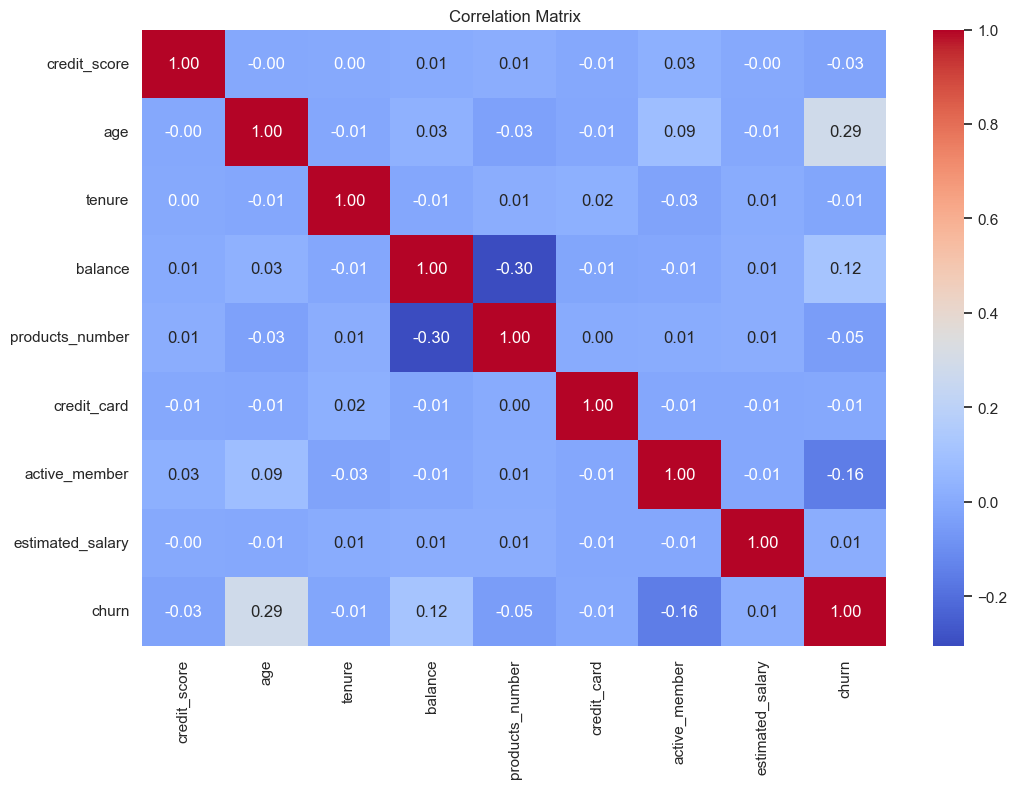

In [33]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig("../images/correlation_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Observation: Most numeric features show low pairwise correlation with each other, suggesting limited multicollinearity in the dataset, a favorable property for modeling. Age shows the strongest correlation with churn (r ≈ 0.29), followed by active membership (r ≈ -0.16) and balance (r ≈ 0.12). Credit score, tenure, and estimated salary all show negligible correlation with churn (|r| ≤ 0.03), consistent with the weak patterns seen in their individual boxplots.
One caveat: products_number shows only a weak linear correlation with churn (r ≈ -0.05), which understates its importance, the countplot of products vs. churn revealed a clear non-monotonic (U-shaped) relationship that a linear correlation coefficient cannot capture. This is a reminder to interpret the correlation matrix alongside the individual feature plots, not in isolation.

## Key Findings

- Older customers churn at meaningfully higher rates than younger customers, and age shows the strongest correlation with churn of any variable.
- Active members show substantially lower churn than inactive members, the second-strongest correlate of churn.
- Customers with 2 products retain best; those with 1 product churn more, and those with 3–4 products churn at very high rates. This non-monotonic pattern means products_number is more informative than its weak linear correlation suggests.
- Churn varies by country (Germany highest) and gender (female higher than male), so both should be retained as categorical features.
- Balance is modestly associated with churn, with churned customers generally holding higher balances and being less likely to have a zero balance.
- Credit score, tenure, estimated salary, and credit card ownership all show weak individual relationships with churn and are unlikely to be strong standalone predictors.
- The dataset shows moderate class imbalance (~80/20), so Precision, Recall, F1-score, and ROC-AUC should be prioritized over accuracy during model evaluation.
- Overall, age, active membership, number of products, country, gender, and balance are expected to contribute most to predictive performance whereas credit score, tenure, salary, and credit card ownership are expected to contribute least on their own.